In [1]:
%pip install pyreadr -q
import pyreadr
import pandas as pd

result = pyreadr.read_r('/kaggle/input/datasets/blitzarc/hospital-triage-data/5v_cleandf.rdata')
df = list(result.values())[0]

print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])
print("\nAll column names:")
for i, col in enumerate(df.columns.tolist()):
    print(f"{i+1}. {col}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.3/788.3 kB 10.2 MB/s eta 0:00:0000:010:01
Note: you may need to restart the kernel to use updated packages.
Total rows: 560486
Total columns: 972

All column names:
1. dep_name
2. esi
3. age
4. gender
5. ethnicity
6. race
7. lang
8. religion
9. maritalstatus
10. employstatus
11. insurance_status
12. disposition
13. arrivalmode
14. arrivalmonth
15. arrivalday
16. arrivalhour_bin
17. previousdispo
18. 2ndarymalig
19. abdomhernia
20. abdomnlpain
21. abortcompl
22. acqfootdef
23. acrenlfail
24. acutecvd
25. acutemi
26. acutphanm
27. adjustmentdisorders
28. adltrespfl
29. alcoholrelateddisorders
30. allergy
31. amniosdx
32. analrectal
33. anemia
34. aneurysm
35. anxietydisorders
36. appendicitis
37. artembolism
38. asppneumon
39. asthma
40. attentiondeficitconductdisruptivebeha
41. backproblem
42. biliarydx
43. birthasphyx
44. birthtrauma
45. bladdercncr
46. blindness
47. bnignutneo
48. bonectcncr
49. bph
50. brainnscan
51. breastcancr
52. bre

In [3]:
print("ESI value counts:")
print(df['esi'].value_counts())
print("\nDisposition value counts:")
print(df['disposition'].value_counts())
print("\nMissing values in key columns:")
key_cols = ['esi', 'disposition', 'age', 'gender',
            'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
            'triage_vital_rr', 'triage_vital_temp']
print(df[key_cols].isnull().sum())

ESI value counts:
esi
3    236229
2    163534
4    125003
5     27992
1      5271
Name: count, dtype: int64

Disposition value counts:
disposition
Discharge    393848
Admit        166638
Name: count, dtype: int64

Missing values in key columns:
esi                    2457
disposition               0
age                      11
gender                    0
triage_vital_hr      166052
triage_vital_sbp     167904
triage_vital_dbp     168063
triage_vital_rr      170487
triage_vital_temp    182985
dtype: int64


In [5]:
basic_cols = ['esi', 'disposition', 'age', 'gender', 'arrivalmode',
              'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
              'triage_vital_rr', 'triage_vital_temp']
cc_cols = [col for col in df.columns if col.startswith('cc_')]
history_cols = [
    'diabmelnoc', 'diabmelwcm', 'asthma', 'htn', 'chfnonhp',
    'coronathero', 'copd', 'dysrhythmia', 'epilepsycnv',
    'osteoarthros', 'backproblem', 'thyroiddsor', 'rheumarth',
    'anxietydisorders', 'mooddisorders', 'chestpain', 'dizziness',
    'headachemig', 'alcoholrelateddisorders', 'substancerelateddisorders',
    'chrkidneydisease', 'hyperlipidem', 'htncomplicn',
    'n_edvisits', 'n_admissions'
]
history_cols = [col for col in history_cols if col in df.columns]
cols_to_keep = basic_cols + cc_cols + history_cols
df = df[cols_to_keep]
print("New shape:", df.shape)
print("History columns found:", len(history_cols))

New shape: (560486, 235)
History columns found: 25


In [6]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

df = df.dropna(subset=['esi'])
df['arrivalmode'] = df['arrivalmode'].fillna(df['arrivalmode'].mode()[0])
df['age'] = df['age'].fillna(df['age'].median()).infer_objects(copy=False)

cc_cols = [col for col in df.columns if col.startswith('cc_')]
df[cc_cols] = df[cc_cols].fillna(0).infer_objects(copy=False)

history_cols = ['diabmelnoc', 'diabmelwcm', 'asthma', 'htn', 'chfnonhp',
                'coronathero', 'copd', 'dysrhythmia', 'epilepsycnv',
                'osteoarthros', 'backproblem', 'thyroiddsor', 'rheumarth',
                'anxietydisorders', 'mooddisorders', 'chestpain', 'dizziness',
                'headachemig', 'alcoholrelateddisorders', 'substancerelateddisorders',
                'chrkidneydisease', 'hyperlipidem', 'htncomplicn']
history_cols = [col for col in history_cols if col in df.columns]
df[history_cols] = df[history_cols].fillna(0).infer_objects(copy=False)
df['n_edvisits'] = df['n_edvisits'].fillna(0)
df['n_admissions'] = df['n_admissions'].fillna(0)

print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nRemaining rows:", len(df))

Missing values after cleaning:
triage_vital_hr      164268
triage_vital_sbp     166114
triage_vital_dbp     166273
triage_vital_rr      168672
triage_vital_temp    181156
dtype: int64

Remaining rows: 558029


In [8]:
vital_cols = ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
              'triage_vital_rr', 'triage_vital_temp']

print("Rows before filtering:", len(df))
df = df.dropna(subset=vital_cols)
print("Rows after filtering:", len(df))
print("Percentage kept:", round(len(df) / 558029 * 100, 1), "%")

Rows before filtering: 369203
Rows after filtering: 369203
Percentage kept: 66.2 %


In [9]:
df = df.copy()
df['esi'] = df['esi'].astype(int)

# Model A label
def map_esi_to_priority(esi):
    if esi in [1, 2, 3]:
        return 'Needs-Immediate-Attention'
    else:
        return 'Can-Wait'

df['priority'] = df['esi'].apply(map_esi_to_priority)

# Model B label
df['disposition_label'] = (df['disposition'] == 'Admit').astype(int)

print("Priority distribution:")
print(df['priority'].value_counts())
print("\nDisposition label distribution:")
print(df['disposition_label'].value_counts())

Priority distribution:
priority
Needs-Immediate-Attention    252467
Can-Wait                     116736
Name: count, dtype: int64

Disposition label distribution:
disposition_label
0    283892
1     85311
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder

cc_cols = [col for col in df.columns if col.startswith('cc_')]

exclude = ['esi', 'disposition', 'age', 'gender', 'arrivalmode',
           'priority', 'disposition_label',
           'gender_encoded']

history_cols = [col for col in df.columns
                if col not in exclude
                and not col.startswith('cc_')
                and 'triage_vital' not in col]

le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'].astype(str))

feature_cols = ['age', 'gender_encoded',
                'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
                'triage_vital_rr', 'triage_vital_temp'] + cc_cols + history_cols

feature_cols = [col for col in feature_cols if col not in
                ['priority', 'disposition_label', 'esi', 'disposition']]

X = df[feature_cols]
y_priority = df['priority']
y_disposition = df['disposition_label']

print("Feature matrix shape:", X.shape)
print("Complaint columns:", len(cc_cols))
print("History columns:", len(history_cols))

Feature matrix shape: (369203, 232)
Complaint columns: 200
History columns: 25


In [11]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_pri_temp, y_pri_test, y_dis_temp, y_dis_test = train_test_split(
    X, y_priority, y_disposition,
    test_size=0.1,
    random_state=42,
    stratify=y_priority
)

X_train, X_val, y_pri_train, y_pri_val, y_dis_train, y_dis_val = train_test_split(
    X_temp, y_pri_temp, y_dis_temp,
    test_size=0.111,
    random_state=42,
    stratify=y_pri_temp
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 295398
Validation set size: 36884
Test set size: 36921


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("Training Model A — Logistic Regression for Priority...")

pipeline_a = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, C=0.5, random_state=42, n_jobs=-1))
])

pipeline_a.fit(X_train, y_pri_train)

y_pred_a_val = pipeline_a.predict(X_val)
y_pred_a_test = pipeline_a.predict(X_test)

print("Validation Accuracy:", round(accuracy_score(y_pri_val, y_pred_a_val) * 100, 2), "%")
print("Test Accuracy:", round(accuracy_score(y_pri_test, y_pred_a_test) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_pri_test, y_pred_a_test))

Training Model A — Logistic Regression for Priority...
Validation Accuracy: 84.85 %
Test Accuracy: 84.48 %

Detailed Report:
                           precision    recall  f1-score   support

                 Can-Wait       0.75      0.76      0.76     11674
Needs-Immediate-Attention       0.89      0.88      0.89     25247

                 accuracy                           0.84     36921
                macro avg       0.82      0.82      0.82     36921
             weighted avg       0.85      0.84      0.85     36921



In [13]:
import numpy as np
import pandas as pd

APP_DETECTABLE_CC = {
    'cc_chestpain', 'cc_shortnessofbreath', 'cc_headache', 'cc_unresponsive',
    'cc_migraine', 'cc_respiratorydistress', 'cc_dizziness', 'cc_nausea', 'cc_emesis',
    'cc_fever', 'cc_abdominalpain', 'cc_backpain', 'cc_chills', 'cc_cough', 'cc_rash',
    'cc_seizures', 'cc_numbness', 'cc_palpitations', 'cc_syncope', 'cc_weakness',
    'cc_trauma', 'cc_laceration', 'cc_burn', 'cc_eyepain', 'cc_earpain', 'cc_sorethroat',
    'cc_urinarytractinfection', 'cc_depression', 'cc_suicidal', 'cc_anxiety',
    'cc_irregularheartbeat', 'cc_hypertension', 'cc_hypotension',
    'cc_overdose-accidental', 'cc_overdose-intentional', 'cc_alcoholintoxication',
    'cc_motorvehiclecrash', 'cc_headinjury', 'cc_kneepain', 'cc_shoulderpain',
    'cc_hippain', 'cc_legpain', 'cc_arminjury', 'cc_footinjury', 'cc_blurredvision',
    'cc_tachycardia', 'cc_dyspnea', 'cc_alteredmentalstatus', 'cc_lossofconsciousness',
    'cc_strokealert', 'cc_gibleeding', 'cc_hematuria', 'cc_epistaxis',
    'cc_hyperglycemia', 'cc_decreasedbloodsugar-symptomatic', 'cc_influenza', 'cc_uri',
    'cc_cellulitis', 'cc_abscess', 'cc_diarrhea', 'cc_constipation', 'cc_poisoning',
    'cc_hallucinations', 'cc_agitation', 'cc_flankpain', 'cc_wheezing',
    'cc_breathingdifficulty', 'cc_chesttightness', 'cc_fulltrauma', 'cc_assaultvictim',
    'cc_neckpain', 'cc_jointinjury', 'cc_skinproblem', 'cc_psychoticsymptoms',
    'cc_epigastricpain'
}
APP_DETECTABLE_HIST = {
    'diabmelnoc', 'htn', 'asthma', 'chfnonhp', 'coronathero', 'copd', 'dysrhythmia',
    'epilepsycnv', 'osteoarthros', 'backproblem', 'thyroiddsor', 'rheumarth',
    'anxietydisorders', 'mooddisorders', 'alcoholrelateddisorders',
    'substancerelateddisorders', 'chrkidneydisease', 'hyperlipidem'
}
VITAL_DEMO_COLS = {
    'age', 'gender_encoded', 'triage_vital_hr', 'triage_vital_sbp',
    'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_temp'
}

# Normal adult vital ranges: (mean, std, clip_min, clip_max)
VITAL_NORMAL_PARAMS = {
    'triage_vital_hr':   (75,  12, 50,  110),
    'triage_vital_sbp':  (118, 16, 90,  160),
    'triage_vital_dbp':  (76,  11, 55,  100),
    'triage_vital_rr':   (16,   2, 12,   22),
    'triage_vital_temp': (36.8, 0.4, 36.0, 38.0),
}


def create_app_like_inputs(X, y, p_mask=0.65, n_aug=500000, seed=42, p_normal_vitals=0.40):
    """
    Builds n_aug synthetic examples matching app inference distribution:
      1. Non-detectable cc_ / history features zeroed.
      2. p_mask fraction of detectable cc_ features randomly zeroed.
      3. For p_normal_vitals fraction of rows, real vitals replaced with
         samples from healthy adult normal ranges — teaches the model
         complaint->outcome mapping even when vitals are completely normal.
    """
    np.random.seed(seed)
    cols = list(X.columns)

    non_det_cc_idx   = [i for i, c in enumerate(cols) if c.startswith('cc_') and c not in APP_DETECTABLE_CC]
    det_cc_idx       = [i for i, c in enumerate(cols) if c.startswith('cc_') and c in APP_DETECTABLE_CC]
    non_det_hist_idx = [i for i, c in enumerate(cols) if not c.startswith('cc_') and c not in VITAL_DEMO_COLS and c not in APP_DETECTABLE_HIST]

    print(f"Detectable cc_ features : {len(det_cc_idx)}")
    print(f"Non-detectable (zeroed) : {len(non_det_cc_idx)} cc_  +  {len(non_det_hist_idx)} history")

    X_arr = X.values
    y_arr = y.values.astype(int)

    rand_idx  = np.random.randint(0, len(X_arr), size=n_aug)
    rand_mask = np.random.random((n_aug, len(det_cc_idx))) < p_mask

    aug_X = X_arr[rand_idx].copy().astype(float)
    aug_X[:, non_det_cc_idx]   = 0
    aug_X[:, non_det_hist_idx] = 0
    for j, ci in enumerate(det_cc_idx):
        aug_X[rand_mask[:, j], ci] = 0

    # Inject normal-range vitals for p_normal_vitals fraction of rows
    nv_rows = np.where(np.random.random(n_aug) < p_normal_vitals)[0]
    for vname, (vmean, vstd, vmin, vmax) in VITAL_NORMAL_PARAMS.items():
        if vname in cols:
            vi = cols.index(vname)
            samples = np.random.normal(vmean, vstd, len(nv_rows))
            aug_X[nv_rows, vi] = np.clip(samples, vmin, vmax)

    aug_df = pd.DataFrame(aug_X, columns=cols)
    aug_y  = pd.Series(y_arr[rand_idx])

    X_out = pd.concat([X.reset_index(drop=True), aug_df], ignore_index=True)
    y_out = pd.concat([pd.Series(y_arr), aug_y],          ignore_index=True)
    return X_out, y_out


print("Creating augmented training set (sparse features + normal vital injection)...")
X_train_aug, y_dis_train_aug = create_app_like_inputs(
    X_train, y_dis_train, p_mask=0.65, n_aug=500000, p_normal_vitals=0.20  # was 0.40
)

X_train_sparse     = X_train_aug.iloc[len(X_train):].reset_index(drop=True)
y_dis_train_sparse = y_dis_train_aug.iloc[len(y_dis_train):].reset_index(drop=True)

print(f"\nSparse training size : {len(X_train_sparse):,}")
print(f"Disposition split:")
print(y_dis_train_sparse.value_counts())
print(f"  (~{round(y_dis_train_sparse.mean()*100, 1)}% Admit, {round((1-y_dis_train_sparse.mean())*100, 1)}% Discharge)")


Creating augmented training set (sparse features + normal vital injection)...
Detectable cc_ features : 74
Non-detectable (zeroed) : 126 cc_  +  7 history

Sparse training size : 500,000
Disposition split:
0    384547
1    115453
Name: count, dtype: int64
  (~23.1% Admit, 76.9% Discharge)


In [14]:
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

scaler_b = StandardScaler()
X_train_sparse_scaled = scaler_b.fit_transform(X_train_sparse)
X_val_scaled          = scaler_b.transform(X_val)
X_test_scaled         = scaler_b.transform(X_test)
X_train_real_scaled   = scaler_b.transform(X_train)

model_b = keras.Sequential([
    keras.layers.Input(shape=(X_train_sparse_scaled.shape[1],)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# ── Phase 1: learn real clinical patterns from actual YNHH records ──────────
model_b.compile(optimizer=keras.optimizers.Adam(1e-3),
                loss='binary_crossentropy', metrics=['accuracy'])

print("Phase 1 — real YNHH data (295K patients)")
model_b.fit(
    X_train_real_scaled, y_dis_train,
    validation_data=(X_val_scaled, y_dis_val),
    epochs=15, batch_size=512, verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(patience=3,
                                              restore_best_weights=True)]
)

# ── Phase 2: fine-tune on sparse data so model handles app-like inputs ───────
# Lower learning rate preserves Phase 1 knowledge while adapting to sparsity.
model_b.compile(optimizer=keras.optimizers.Adam(3e-4),
                loss='binary_crossentropy', metrics=['accuracy'])

print("\nPhase 2 — sparse augmented data (500K, fine-tune)")
history_b = model_b.fit(
    X_train_sparse_scaled, y_dis_train_sparse,
    validation_data=(X_val_scaled, y_dis_val),
    epochs=20, batch_size=512, verbose=1,
    class_weight={0: 1.0, 1: 2.0},
    callbacks=[keras.callbacks.EarlyStopping(patience=3,
                                              restore_best_weights=True)]
)

y_pred_b_prob = model_b.predict(X_test_scaled)
y_pred_b      = (y_pred_b_prob > 0.5).astype(int).flatten()

print(f"\nTest Accuracy : {round(accuracy_score(y_dis_test, y_pred_b)*100, 2)} %")
print(classification_report(y_dis_test, y_pred_b, target_names=['Discharge', 'Admit']))

print("\n── Sanity check ──")
import pandas as pd
cases = [
    ("Cough + cold  (expect Discharge)", {'cc_cough': 1, 'cc_uri': 1}),
    ("Rash only     (expect Discharge)", {'cc_rash': 1}),
    ("Sore throat   (expect Discharge)", {'cc_sorethroat': 1}),
    ("Chest pain    (expect Admit)    ", {'cc_chestpain': 1}),
    ("Chest+SOB     (expect Admit)    ", {'cc_chestpain': 1, 'cc_shortnessofbreath': 1}),
    ("Stroke alert  (expect Admit)    ", {'cc_strokealert': 1}),
    ("Seizure       (expect Admit)    ", {'cc_seizures': 1}),
]
base = {'age':45,'gender_encoded':0,'triage_vital_hr':82,'triage_vital_sbp':128,
        'triage_vital_dbp':82,'triage_vital_rr':17,'triage_vital_temp':37.1}
for label, flags in cases:
    fv = {c: 0 for c in X_train.columns}
    fv.update(base); fv.update(flags)
    xin  = pd.DataFrame([[fv.get(c,0) for c in X_train.columns]], columns=X_train.columns)
    prob = float(model_b.predict(scaler_b.transform(xin), verbose=0)[0][0])
    pred = "Admit" if prob >= 0.30 else "Discharge"
    print(f"  {label}  P(Admit)={prob:.3f}  -> {pred}")


2026-05-20 14:26:21.390776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779287181.665925      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779287181.740367      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779287182.438236      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779287182.438279      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779287182.438282      57 computation_placer.cc:177] computation placer alr

Phase 1 — real YNHH data (295K patients)
Epoch 1/15
577/577 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7751 - loss: 0.4896 - val_accuracy: 0.8192 - val_loss: 0.3989
Epoch 2/15
577/577 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8167 - loss: 0.4021 - val_accuracy: 0.8227 - val_loss: 0.3954
Epoch 3/15
577/577 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8201 - loss: 0.3949 - val_accuracy: 0.8227 - val_loss: 0.3929
Epoch 4/15
577/577 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8221 - loss: 0.3919 - val_accuracy: 0.8243 - val_loss: 0.3922
Epoch 5/15
577/577 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8242 - loss: 0.3871 - val_accuracy: 0.8235 - val_loss: 0.3902
Epoch 6/15
577/577 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8222 - loss: 0.3901 - val_accuracy: 0.8249 - val_loss: 0.3897
Epoch 7/15
577/577 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8255 - loss: 0.3849 - val_accuracy: 0.8244 - val_loss: 0.3880
Epoch 8/15
577/577 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accur

In [34]:
import joblib

# Save Model A pipeline — includes scaler automatically
joblib.dump(pipeline_a, 'model_a_pipeline.pkl')
print("Model A saved — model_a_pipeline.pkl")

# Save Model B neural network
model_b.save('model_b_nn.keras')
print("Model B saved — model_b_nn.keras")

# Save Model B scaler separately
joblib.dump(scaler_b, 'model_b_scaler.pkl')
print("Model B scaler saved — model_b_scaler.pkl")

# Save label encoders
joblib.dump(le_gender, 'le_gender.pkl')
print("Label encoders saved")

# Save feature column names
joblib.dump(feature_cols, 'feature_cols.pkl')
print("Feature columns saved — feature_cols.pkl")

print("\nAll files saved successfully.")
print("Download these files from Kaggle before closing the notebook.")

Model A saved — model_a_pipeline.pkl
Model B saved — model_b_nn.keras
Model B scaler saved — model_b_scaler.pkl
Label encoders saved
Feature columns saved — feature_cols.pkl

All files saved successfully.
Download these files from Kaggle before closing the notebook.


MODEL A — Logistic Regression — Priority
Test Accuracy: 84.48%

Classification Report:
                           precision    recall  f1-score   support

                 Can-Wait       0.75      0.76      0.76     11674
Needs-Immediate-Attention       0.89      0.88      0.89     25247

                 accuracy                           0.84     36921
                macro avg       0.82      0.82      0.82     36921
             weighted avg       0.85      0.84      0.85     36921



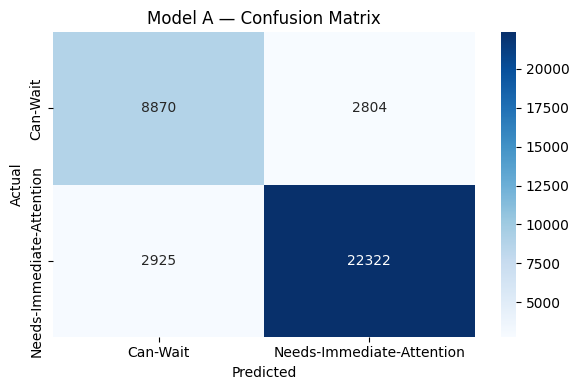

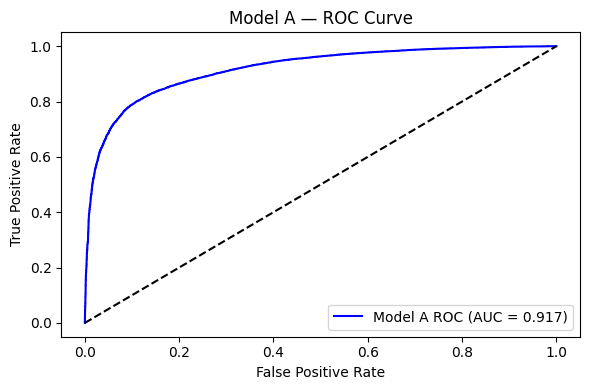


MODEL B — Neural Network — Disposition
1154/1154 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Test Accuracy: 80.39%

Classification Report:
              precision    recall  f1-score   support

   Discharge       0.89      0.85      0.87     28406
       Admit       0.56      0.65      0.61      8515

    accuracy                           0.80     36921
   macro avg       0.73      0.75      0.74     36921
weighted avg       0.82      0.80      0.81     36921



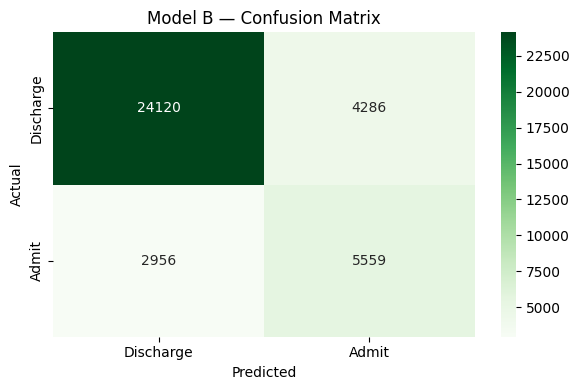

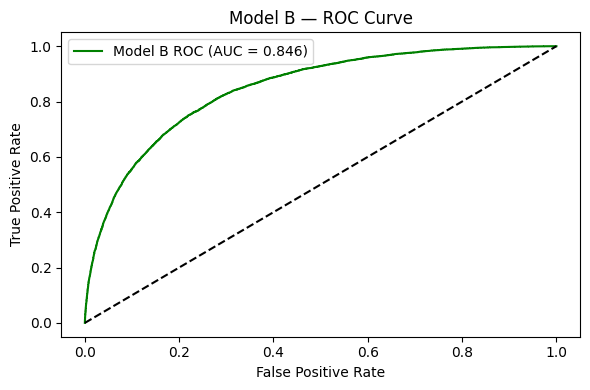


BASELINE — Dummy Classifier Comparison

Model A — Logistic Regression: 84.48%
Model A — Naive Baseline:       68.38%
Improvement:                    +16.1%

Model B — Neural Network:       80.39%
Model B — Naive Baseline:       76.94%
Improvement:                    +3.45%


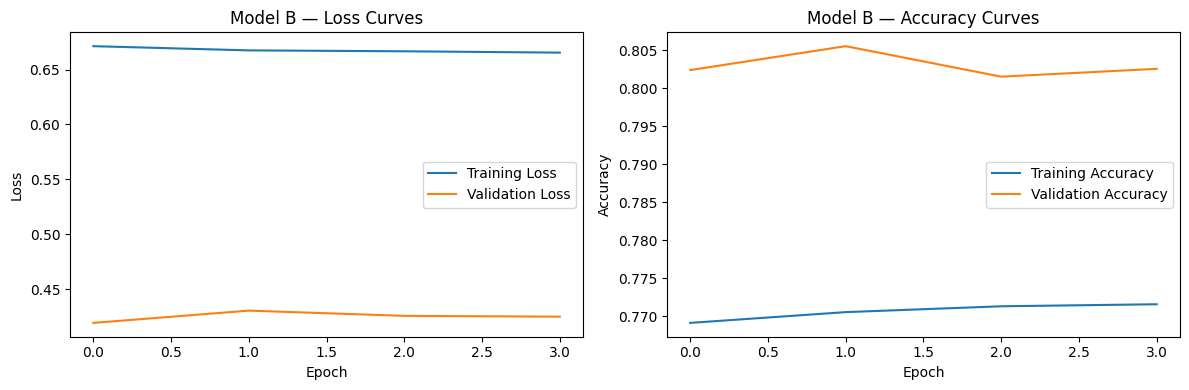


GENERALIZATION GAP
Model A — Train: 84.91% | Test: 84.48% | Gap: 0.43%
Model B — Train: 77.16% | Val: 80.26% | Gap: -3.1%


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, roc_curve, auc, 
                             classification_report, accuracy_score,
                             RocCurveDisplay)
from sklearn.dummy import DummyClassifier

# ── Model A Evaluation ──────────────────────────────────────────
print("=" * 50)
print("MODEL A — Logistic Regression — Priority")
print("=" * 50)

y_pred_a = pipeline_a.predict(X_test)
y_pred_a_prob = pipeline_a.predict_proba(X_test)[:, 1]

print(f"Test Accuracy: {round(accuracy_score(y_pri_test, y_pred_a) * 100, 2)}%")
print("\nClassification Report:")
print(classification_report(y_pri_test, y_pred_a))

# Confusion Matrix — Model A
cm_a = confusion_matrix(y_pri_test, y_pred_a)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=pipeline_a.classes_,
            yticklabels=pipeline_a.classes_)
plt.title('Model A — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve — Model A
fpr_a, tpr_a, _ = roc_curve(y_pri_test, y_pred_a_prob,
                              pos_label='Needs-Immediate-Attention')
roc_auc_a = auc(fpr_a, tpr_a)
plt.figure(figsize=(6, 4))
plt.plot(fpr_a, tpr_a, color='blue', label=f'Model A ROC (AUC = {roc_auc_a:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Model A — ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# ── Model B Evaluation ──────────────────────────────────────────
print("\n" + "=" * 50)
print("MODEL B — Neural Network — Disposition")
print("=" * 50)

y_pred_b_prob = model_b.predict(X_test_scaled).flatten()
y_pred_b = (y_pred_b_prob > 0.5).astype(int)

print(f"Test Accuracy: {round(accuracy_score(y_dis_test, y_pred_b) * 100, 2)}%")
print("\nClassification Report:")
print(classification_report(y_dis_test, y_pred_b,
                            target_names=['Discharge', 'Admit']))

# Confusion Matrix — Model B
cm_b = confusion_matrix(y_dis_test, y_pred_b)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Discharge', 'Admit'],
            yticklabels=['Discharge', 'Admit'])
plt.title('Model B — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC Curve — Model B
fpr_b, tpr_b, _ = roc_curve(y_dis_test, y_pred_b_prob)
roc_auc_b = auc(fpr_b, tpr_b)
plt.figure(figsize=(6, 4))
plt.plot(fpr_b, tpr_b, color='green', label=f'Model B ROC (AUC = {roc_auc_b:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Model B — ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

# ── Baseline Comparison ─────────────────────────────────────────
print("\n" + "=" * 50)
print("BASELINE — Dummy Classifier Comparison")
print("=" * 50)

# Baseline for Model A
baseline_a = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_a.fit(X_train, y_pri_train)
baseline_a_acc = accuracy_score(y_pri_test, baseline_a.predict(X_test))

# Baseline for Model B
baseline_b = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_b.fit(X_train, y_dis_train)
baseline_b_acc = accuracy_score(y_dis_test, baseline_b.predict(X_test))

print(f"\nModel A — Logistic Regression: {round(accuracy_score(y_pri_test, y_pred_a) * 100, 2)}%")
print(f"Model A — Naive Baseline:       {round(baseline_a_acc * 100, 2)}%")
print(f"Improvement:                    +{round((accuracy_score(y_pri_test, y_pred_a) - baseline_a_acc) * 100, 2)}%")

print(f"\nModel B — Neural Network:       {round(accuracy_score(y_dis_test, y_pred_b) * 100, 2)}%")
print(f"Model B — Naive Baseline:       {round(baseline_b_acc * 100, 2)}%")
print(f"Improvement:                    +{round((accuracy_score(y_dis_test, y_pred_b) - baseline_b_acc) * 100, 2)}%")

# Loss curves for Model B
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_b.history['loss'], label='Training Loss')
plt.plot(history_b.history['val_loss'], label='Validation Loss')
plt.title('Model B — Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_b.history['accuracy'], label='Training Accuracy')
plt.plot(history_b.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model B — Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
# Generalization Gap
train_acc_a = pipeline_a.score(X_train, y_pri_train)
test_acc_a = pipeline_a.score(X_test, y_pri_test)
train_acc_b = history_b.history['accuracy'][-1]
val_acc_b = history_b.history['val_accuracy'][-1]

print("\n" + "=" * 50)
print("GENERALIZATION GAP")
print("=" * 50)
print(f"Model A — Train: {round(train_acc_a*100,2)}% | Test: {round(test_acc_a*100,2)}% | Gap: {round((train_acc_a-test_acc_a)*100,2)}%")
print(f"Model B — Train: {round(train_acc_b*100,2)}% | Val: {round(val_acc_b*100,2)}% | Gap: {round((train_acc_b-val_acc_b)*100,2)}%")